In [54]:
import torch
import torch.nn as nn
from pathlib import Path

from src.models import SimpleLinearRegressionModel
from src.data_helpers import dummy_data_lin_reg
from src.ml_helpers import train_test_split
from src.plotting_helpers import plot_predictions, plot_loss_curves

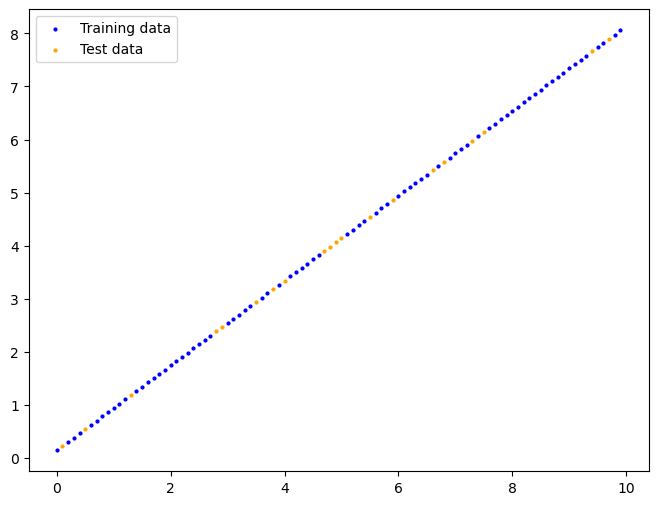

In [44]:
# Create dummy data
X, y = dummy_data_lin_reg(weight=0.8, bias=0.14, start=0, end=10, step=0.1)

# Split the data
X_train, y_train, X_test, y_test = train_test_split(X, y, train_size=0.8)

# Visualization
plot_predictions(train_data=X_train, train_labels=y_train,
                 test_data=X_test, test_labels=y_test, filename='lin_reg_model_no_pred.png')

In [45]:
# Write device-agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Move all tensors to the same device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [46]:
# Initialize with random seed for reproducibility
torch.manual_seed(16)
torch.cuda.manual_seed(16)

In [47]:
# Instantiate model
lin_reg_model = SimpleLinearRegressionModel()

In [48]:
# Define model optimizer
optimizer = torch.optim.SGD(
    params=lin_reg_model.parameters(),
    lr = 0.001
)

loss_func = nn.L1Loss()

In [49]:
# Track losses
epoch_vals = []
train_loss_vals = []
test_loss_vals = []

# Training loop
epochs = 2000

for epoch in range(epochs):
    lin_reg_model.train()

    # Forward pass
    y_pred = lin_reg_model(X_train)

    # Calculate loss
    loss = loss_func(y_pred, y_train)

    # Zero out optimizer gradients
    # PyTorch would otherwise accumulate them through the steps
    optimizer.zero_grad()

    # Backpropagation to compute the gradient of the loss with respect to
    # all the model parameters (weights and biases) that have requires_grad=True
    loss.backward()

    # Update the model's parameters using the calculated gradients
    optimizer.step()

    # Testing loop
    lin_reg_model.eval()
    with torch.inference_mode():
        test_pred = lin_reg_model(X_test)

        test_loss = loss_func(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_vals.append(epoch)
        train_loss_vals.append(loss)
        test_loss_vals.append(test_loss)
        # print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")

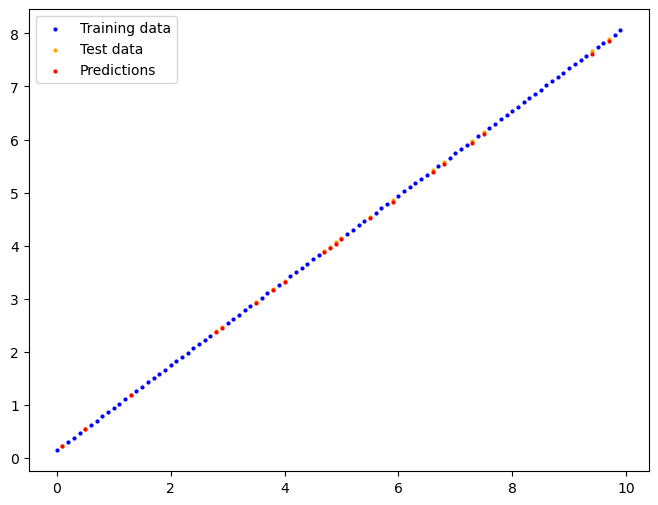

In [50]:
# Visualize predictions
lin_reg_model.eval()
with torch.inference_mode():
    plot_predictions(train_data=X_train, train_labels=y_train,
                     test_data=X_test, test_labels=y_test,
                     predictions=test_pred,
                     filename='lin_reg_model_pred.png')

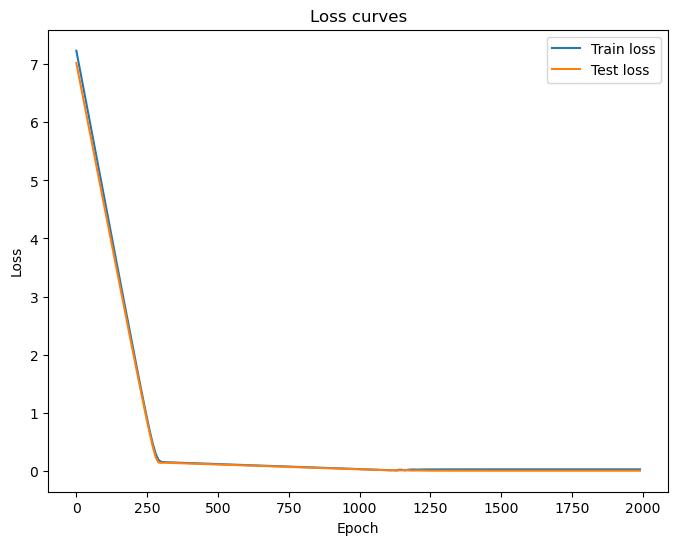

In [51]:
# Plot loss curves
plot_loss_curves(epoch_vals, train_loss_vals, test_loss_vals,
                 filename='lin_reg_model_loss.png')

In [52]:
# Saving the model
model_path = Path("models")
model_path.mkdir(parents=True, exist_ok=True)
model_name = "Workflow_lesson_model_0.pth"
model_save_path = model_path / model_name

torch.save(obj=lin_reg_model.state_dict(), f=model_save_path) # save a PyTorch object in pickle format

In [53]:
# Loading model
loaded_model_0 = SimpleLinearRegressionModel() # create a model instance
loaded_model_0.load_state_dict( # load a model's saved state dict
    torch.load( # load saved PyTorch object
        f=model_save_path,
        map_location=torch.device('cpu'),
        weights_only=False
    )
)

<All keys matched successfully>